# 04 - Measurement-first validation

Notebooks 02 and 03 used correlation between representational dissimilarity matrices (RDMs) as the main outcome. That is standard RSA, but it is an indirect summary: with six targets it correlates the ranks of only 15 pairwise distances. This notebook asks simpler questions first.

1. Can independent trials identify which of the six targets was seen or imagined?
2. Can vision-derived target prototypes identify imagery trials above 1/6 chance?
3. Does that result survive vision trials where the visible cue letter mismatches the image?
4. Are target differences reproducible with a crossvalidated dot-product distance whose null expectation is zero?
5. Only after those checks: how stable is the perception-imagery RDM correlation to targets, and how high is the group RSA noise ceiling?

All eight subjects are included. Results are theory-guided but exploratory because Notebooks 02 and 03 have already been inspected.

In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'nsdimagery').is_dir():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / 'nsdimagery').is_dir():
    raise RuntimeError('Start Jupyter from the repository root or notebooks/.')
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from nsdimagery import (
    balanced_split_identification, build_event_table, correlation_rdm,
    crossvalidated_dot_rdm, exact_class_label_permutation_test,
    exact_label_permutation_test, exact_sign_flip_test, extract_masked_betas,
    find_data_root, leave_one_target_out_rdm_spearman, load_roi,
    load_target_table, nearest_centroid_predict, paths_for_subject,
    rdm_noise_ceiling, rdm_spearman, upper_triangle, zscore_within_groups,
)

sns.set_theme(style='whitegrid', context='notebook')
DATA_ROOT = find_data_root(REPO_ROOT)
print('Python:', sys.version.split()[0])
print('Repository:', REPO_ROOT)
print('Data root:', DATA_ROOT)

Python: 3.12.13
Repository: /home/jovyan/NHprojectNSDimagery
Data root: /home/jovyan/NHprojectNSDimagery/data/nsd


## 1. Analysis contract

The primary outcomes are identification accuracies and crossvalidated target differences, not visual inspection of ordinary RDM heatmaps. Correlation-distance RSA remains a secondary relational summary. Exact sign flips test subject-level effects against chance or zero; they do not convert this already-inspected dataset into a preregistered confirmation.

In [2]:
SUBJECTS = tuple(range(1, 9))
STIMULUS_SETS = ('A', 'B')
ROI_SPECS = {
    'nsdgeneral': {'mask_name': 'nsdgeneral', 'labels': None},
    'early_visual': {'mask_name': 'prf-visualrois', 'labels': tuple(range(1, 7))},
    'higher_visual': {'mask_name': 'streams', 'labels': (5, 6, 7)},
}
ROI_ORDER = list(ROI_SPECS)
MAX_VOXELS_PER_ROI = 1200
N_VISION_SPLITS = 100
BASE_SEED = 2026
CHANCE = 1 / 6

CACHE_DIR = DATA_ROOT / 'derived' / 'notebook03_beta_cache'
OUTPUT_DIR = REPO_ROOT / 'outputs' / '04_measurement_first_validation'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('All subjects:', SUBJECTS)
print('Six-way chance:', f'{CHANCE:.3f}')
print('Reusing beta cache:', CACHE_DIR)

All subjects: (1, 2, 3, 4, 5, 6, 7, 8)
Six-way chance: 0.167
Reusing beta cache: /home/jovyan/NHprojectNSDimagery/data/nsd/derived/notebook03_beta_cache


## 2. Load the same normalized ROI patterns

This reuses Notebook 03's beta cache. Every voxel is Z-scored across trials separately within each run. Vision target labels use the image actually shown (`CONDITION`); imagery labels use the instructed cue. We additionally map the vision cue to a target number for the cue-confound controls.

In [3]:
targets = load_target_table(DATA_ROOT)
cue_lookup = {
    (row.stimulus_set, str(row.target_code)): int(row.target_number)
    for row in targets.itertuples()
}

def cache_path(subject, roi_name, seed):
    voxel_token = 'all' if MAX_VOXELS_PER_ROI is None else str(MAX_VOXELS_PER_ROI)
    return CACHE_DIR / f'subj{subject:02d}_{roi_name}_n{voxel_token}_seed{seed}.npz'

def load_or_extract(subject, roi_name, roi_index):
    spec = ROI_SPECS[roi_name]
    seed = BASE_SEED + subject * 100 + roi_index
    path = cache_path(subject, roi_name, seed)
    if path.is_file():
        with np.load(path) as cached:
            return cached['betas'], cached['coordinates']
    mask, _ = load_roi(DATA_ROOT, subject, spec['mask_name'])
    betas, coordinates = extract_masked_betas(
        paths_for_subject(DATA_ROOT, subject)['beta'], mask,
        labels=spec['labels'], max_voxels=MAX_VOXELS_PER_ROI, seed=seed,
    )
    np.savez_compressed(path, betas=betas, coordinates=coordinates)
    return betas, coordinates

subject_events = {}
normalized_data = {}
for subject in SUBJECTS:
    print(f'subj{subject:02d}')
    events = build_event_table(DATA_ROOT, subject).reset_index(drop=True)
    events['cue_target_number'] = [
        cue_lookup[(stimulus_set, str(cue))]
        for stimulus_set, cue in zip(events['stimulus_set'], events['CUE'])
    ]
    events['cue_matches_condition'] = events['CUE'].astype(str).eq(
        events['CONDITION'].astype(str)
    )
    subject_events[subject] = events
    for roi_index, roi_name in enumerate(ROI_ORDER):
        all_betas, coordinates = load_or_extract(subject, roi_name, roi_index)
        trial_patterns = all_betas[events['beta_index'].to_numpy()]
        normalized_data[(subject, roi_name)] = zscore_within_groups(
            trial_patterns, events['run_name'].to_numpy()
        )
        print(f'  {roi_name}: {len(coordinates)} voxels')

subj01
  nsdgeneral: 1200 voxels
  early_visual: 1200 voxels
  higher_visual: 1200 voxels
subj02
  nsdgeneral: 1200 voxels
  early_visual: 1200 voxels
  higher_visual: 1200 voxels
subj03
  nsdgeneral: 1200 voxels
  early_visual: 1200 voxels
  higher_visual: 1200 voxels
subj04
  nsdgeneral: 1200 voxels
  early_visual: 1200 voxels
  higher_visual: 1200 voxels
subj05
  nsdgeneral: 1200 voxels
  early_visual: 1200 voxels
  higher_visual: 1200 voxels
subj06
  nsdgeneral: 1200 voxels
  early_visual: 1200 voxels
  higher_visual: 1200 voxels
subj07
  nsdgeneral: 1200 voxels
  early_visual: 1200 voxels
  higher_visual: 1200 voxels
subj08
  nsdgeneral: 1200 voxels
  early_visual: 1200 voxels
  higher_visual: 1200 voxels


## 3. Can the six targets be identified within each condition?

Vision accuracy is the median over 100 symmetric balanced 4-versus-4 trial splits. Imagery uses the independent runs: train on `imgX_1`, test individual trials in `imgX_2`, then reverse. Chance is 1/6. This is a direct measurement-validity check that the ordinary RDM heatmap could not provide.

In [4]:
identification_rows = []
for subject in SUBJECTS:
    events = subject_events[subject]
    for roi_index, roi_name in enumerate(ROI_ORDER):
        patterns = normalized_data[(subject, roi_name)]
        for set_index, stimulus_set in enumerate(STIMULUS_SETS):
            vision = events[events['task'].eq('vision') & events['stimulus_set'].eq(stimulus_set)]
            positions = vision.index.to_numpy()
            vision_splits = balanced_split_identification(
                patterns[positions], vision['target_number'].to_numpy(),
                n_splits=N_VISION_SPLITS,
                seed=BASE_SEED + subject * 1000 + roi_index * 10 + set_index,
            )
            identification_rows.append({
                'subject': subject, 'stimulus_set': stimulus_set, 'roi': roi_name,
                'task': 'vision', 'accuracy': float(np.median(vision_splits)),
                'accuracy_q25': float(np.quantile(vision_splits, .25)),
                'accuracy_q75': float(np.quantile(vision_splits, .75)),
            })

            imagery = events[events['task'].eq('imagery') & events['stimulus_set'].eq(stimulus_set)]
            first = imagery[imagery['run_name'].str.endswith('_1')]
            second = imagery[imagery['run_name'].str.endswith('_2')]
            predicted_12 = nearest_centroid_predict(
                patterns[first.index], first['target_number'], patterns[second.index]
            )
            predicted_21 = nearest_centroid_predict(
                patterns[second.index], second['target_number'], patterns[first.index]
            )
            predicted = np.concatenate([predicted_12, predicted_21])
            observed = np.concatenate([second['target_number'], first['target_number']])
            permutation = exact_class_label_permutation_test(predicted, observed)
            identification_rows.append({
                'subject': subject, 'stimulus_set': stimulus_set, 'roi': roi_name,
                'task': 'imagery', 'accuracy': permutation['accuracy'],
                'accuracy_q25': np.nan, 'accuracy_q75': np.nan,
            })

identification = pd.DataFrame(identification_rows)
group_identification_rows = []
for keys, frame in identification.groupby(['stimulus_set', 'task', 'roi']):
    test = exact_sign_flip_test(frame['accuracy'].to_numpy() - CHANCE)
    group_identification_rows.append({
        **dict(zip(['stimulus_set', 'task', 'roi'], keys)),
        'mean_accuracy': frame['accuracy'].mean(),
        'median_accuracy': frame['accuracy'].median(),
        'p_above_chance': test['p_greater'],
    })
group_identification = pd.DataFrame(group_identification_rows)
display(group_identification.sort_values(['stimulus_set', 'task', 'roi']))

,stimulus_set,task,roi,mean_accuracy,median_accuracy,p_above_chance
0,A,imagery,early_visual,0.218750,0.244792,0.054688
1,A,imagery,higher_visual,0.184896,0.182292,0.250000
2,A,imagery,nsdgeneral,0.244792,0.255208,0.007812
3,A,vision,early_visual,0.529948,0.552083,0.003906
4,A,vision,higher_visual,0.101562,0.093750,1.000000
5,A,vision,nsdgeneral,0.269531,0.291667,0.019531
6,B,imagery,early_visual,0.174479,0.166667,0.363281
7,B,imagery,higher_visual,0.208333,0.197917,0.011719
8,B,imagery,nsdgeneral,0.229167,0.229167,0.007812
9,B,vision,early_visual,0.466146,0.494792,0.003906


Text(0.5, 1.02, 'Independent-trial target identification')

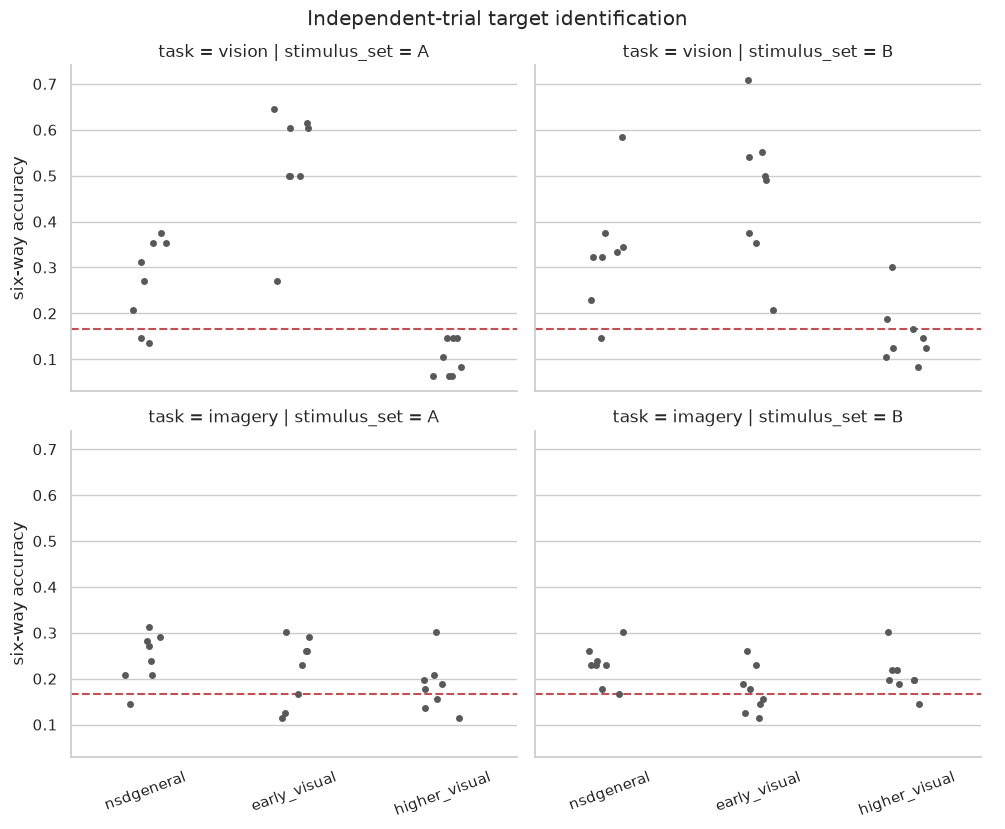

In [5]:
g = sns.catplot(
    data=identification, x='roi', y='accuracy', col='stimulus_set', row='task',
    order=ROI_ORDER, kind='strip', jitter=.14, color='0.35', height=4, aspect=1.25,
)
for ax in g.axes.flat:
    ax.axhline(CHANCE, color='#c44e52', linestyle='--', label='1/6 chance')
    ax.tick_params(axis='x', rotation=20)
g.set_axis_labels('', 'six-way accuracy')
g.fig.suptitle('Independent-trial target identification', y=1.02)

## 4. Can vision prototypes identify imagery targets?

The main statistic is six-way imagery-trial accuracy using target centroids learned from vision. Three controls matter:

- `all_actual`: label vision trials by the image actually shown.
- `mismatch_actual`: train only where the visible cue letter and shown image differ, still labeling by the image. Persistence here argues against a shared-letter explanation.
- `all_cue`: label vision trials by the visible cue instead. Higher cue-labeled than image-labeled accuracy warns that the result may reflect cue processing.

This is more directly interpretable than an RDM rho: chance is 16.7%, and every test trial has a correct/incorrect outcome.

In [6]:
cross_rows = []
for subject in SUBJECTS:
    events = subject_events[subject]
    for roi_name in ROI_ORDER:
        patterns = normalized_data[(subject, roi_name)]
        for stimulus_set in STIMULUS_SETS:
            vision = events[events['task'].eq('vision') & events['stimulus_set'].eq(stimulus_set)]
            imagery = events[events['task'].eq('imagery') & events['stimulus_set'].eq(stimulus_set)]
            specifications = {
                'all_actual': (vision, 'target_number'),
                'matched_actual': (vision[vision['cue_matches_condition']], 'target_number'),
                'mismatch_actual': (vision[~vision['cue_matches_condition']], 'target_number'),
                'all_cue': (vision, 'cue_target_number'),
            }
            for control, (training, label_column) in specifications.items():
                counts = training.groupby(label_column).size()
                if len(counts) != 6 or counts.min() < 1:
                    raise ValueError(f'{subject=} {stimulus_set=} {control=} lacks a target')
                predicted = nearest_centroid_predict(
                    patterns[training.index], training[label_column], patterns[imagery.index]
                )
                test = exact_class_label_permutation_test(
                    predicted, imagery['target_number'].to_numpy()
                )
                cross_rows.append({
                    'subject': subject, 'stimulus_set': stimulus_set, 'roi': roi_name,
                    'control': control, 'accuracy': test['accuracy'],
                    'subject_p': test['p_greater'],
                    'min_training_trials_per_target': int(counts.min()),
                })

cross_identification = pd.DataFrame(cross_rows)
cross_group_rows = []
for keys, frame in cross_identification.groupby(['stimulus_set', 'roi', 'control']):
    test = exact_sign_flip_test(frame['accuracy'].to_numpy() - CHANCE)
    cross_group_rows.append({
        **dict(zip(['stimulus_set', 'roi', 'control'], keys)),
        'mean_accuracy': frame['accuracy'].mean(),
        'median_accuracy': frame['accuracy'].median(),
        'p_above_chance': test['p_greater'],
    })
cross_group = pd.DataFrame(cross_group_rows)
display(cross_group.sort_values(['stimulus_set', 'roi', 'control']))

,stimulus_set,roi,control,mean_accuracy,median_accuracy,p_above_chance
0,A,early_visual,all_actual,0.273438,0.260417,0.007812
1,A,early_visual,all_cue,0.226562,0.229167,0.019531
2,A,early_visual,matched_actual,0.242188,0.223958,0.007812
3,A,early_visual,mismatch_actual,0.244792,0.229167,0.015625
4,A,higher_visual,all_actual,0.179688,0.171875,0.234375
5,A,higher_visual,all_cue,0.194010,0.213542,0.062500
6,A,higher_visual,matched_actual,0.187500,0.192708,0.031250
7,A,higher_visual,mismatch_actual,0.171875,0.192708,0.433594
8,A,nsdgeneral,all_actual,0.244792,0.234375,0.003906
9,A,nsdgeneral,all_cue,0.231771,0.229167,0.003906


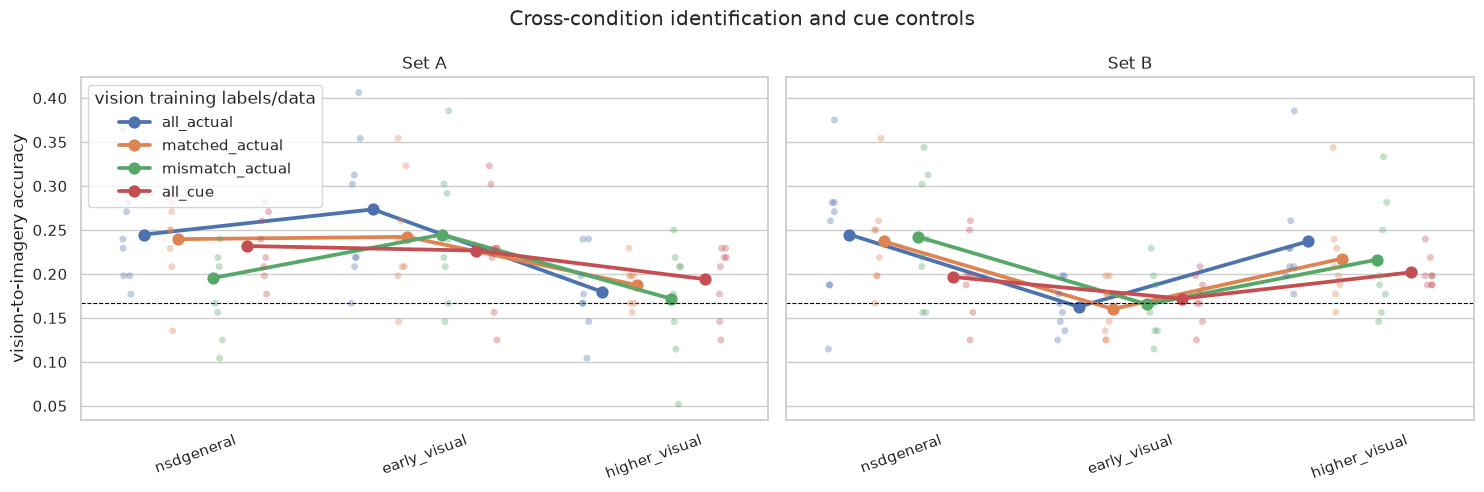

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, stimulus_set in zip(axes, STIMULUS_SETS):
    frame = cross_identification[cross_identification['stimulus_set'].eq(stimulus_set)]
    sns.pointplot(
        data=frame, x='roi', y='accuracy', hue='control', order=ROI_ORDER,
        errorbar=None, dodge=.45, markers='o', linestyles='-', ax=ax,
    )
    sns.stripplot(
        data=frame, x='roi', y='accuracy', hue='control', order=ROI_ORDER,
        dodge=True, jitter=.08, alpha=.35, legend=False, ax=ax,
    )
    ax.axhline(CHANCE, color='black', linestyle='--', linewidth=.8)
    ax.set(title=f'Set {stimulus_set}', xlabel='', ylabel='vision-to-imagery accuracy')
    ax.tick_params(axis='x', rotation=20)
axes[1].get_legend().remove()
axes[0].legend(title='vision training labels/data', bbox_to_anchor=(0, 1), loc='upper left')
fig.suptitle('Cross-condition identification and cue controls')
plt.tight_layout()

## 5. Crossvalidated target differences

Ordinary RDM distances are positive even under pure noise. Here, for each target pair $(i,j)$ and two independent partitions $A,B$, we compute

$$d_{ij}^{cv}=\frac{(\mu_i^A-\mu_j^A)^T(\mu_i^B-\mu_j^B)}{V}.$$

Its expectation is zero if the target difference is not reproducible, positive if the contrast points in a consistent voxel-space direction, and it may be negative because it is unbiased. This is an unwhitened relative of crossnobis distance. Vision uses repeated balanced splits; imagery uses run 1 versus run 2. `vision_imagery` directly compares vision target contrasts with imagery target contrasts in the same voxels.

In [8]:
def balanced_crossvalidated_rdm(patterns, targets, *, n_splits, seed):
    targets = np.asarray(targets)
    indices = {target: np.flatnonzero(targets == target) for target in np.unique(targets)}
    rng = np.random.default_rng(seed)
    rdms = []
    for _ in range(n_splits):
        first, second = [], []
        for target, target_indices in indices.items():
            shuffled = rng.permutation(target_indices)
            middle = len(shuffled) // 2
            first.extend(shuffled[:middle])
            second.extend(shuffled[middle:])
        rdm, order = crossvalidated_dot_rdm(
            patterns[first], targets[first], patterns[second], targets[second]
        )
        rdms.append(rdm)
    return np.mean(rdms, axis=0), order

dot_rows = []
dot_rdms = {}
for subject in SUBJECTS:
    events = subject_events[subject]
    for roi_index, roi_name in enumerate(ROI_ORDER):
        patterns = normalized_data[(subject, roi_name)]
        for set_index, stimulus_set in enumerate(STIMULUS_SETS):
            vision = events[events['task'].eq('vision') & events['stimulus_set'].eq(stimulus_set)]
            imagery = events[events['task'].eq('imagery') & events['stimulus_set'].eq(stimulus_set)]
            first = imagery[imagery['run_name'].str.endswith('_1')]
            second = imagery[imagery['run_name'].str.endswith('_2')]
            vision_rdm, order = balanced_crossvalidated_rdm(
                patterns[vision.index], vision['target_number'],
                n_splits=N_VISION_SPLITS,
                seed=BASE_SEED + subject * 1000 + roi_index * 10 + set_index,
            )
            imagery_rdm, imagery_order = crossvalidated_dot_rdm(
                patterns[first.index], first['target_number'],
                patterns[second.index], second['target_number'],
            )
            cross_rdm, cross_order = crossvalidated_dot_rdm(
                patterns[vision.index], vision['target_number'],
                patterns[imagery.index], imagery['target_number'],
            )
            assert np.array_equal(order, imagery_order) and np.array_equal(order, cross_order)
            for comparison, rdm in {
                'vision': vision_rdm, 'imagery': imagery_rdm,
                'vision_imagery': cross_rdm,
            }.items():
                dot_rdms[(subject, roi_name, stimulus_set, comparison)] = rdm
                dot_rows.append({
                    'subject': subject, 'stimulus_set': stimulus_set, 'roi': roi_name,
                    'comparison': comparison,
                    'mean_pair_distance': upper_triangle(rdm).mean(),
                })

dot_metrics = pd.DataFrame(dot_rows)
dot_group_rows = []
for keys, frame in dot_metrics.groupby(['stimulus_set', 'roi', 'comparison']):
    test = exact_sign_flip_test(frame['mean_pair_distance'].to_numpy())
    dot_group_rows.append({
        **dict(zip(['stimulus_set', 'roi', 'comparison'], keys)),
        'mean_pair_distance': frame['mean_pair_distance'].mean(),
        'median_pair_distance': frame['mean_pair_distance'].median(),
        'p_greater': test['p_greater'],
    })
dot_group = pd.DataFrame(dot_group_rows)
display(dot_group.sort_values(['stimulus_set', 'comparison', 'roi']))

,stimulus_set,roi,comparison,mean_pair_distance,median_pair_distance,p_greater
0,A,early_visual,imagery,0.021863,0.031044,0.027344
3,A,higher_visual,imagery,0.008776,0.013242,0.019531
6,A,nsdgeneral,imagery,0.018375,0.018060,0.023438
1,A,early_visual,vision,0.261649,0.256128,0.003906
4,A,higher_visual,vision,-0.018374,-0.026576,0.925781
7,A,nsdgeneral,vision,0.069822,0.070266,0.007812
2,A,early_visual,vision_imagery,0.048129,0.055906,0.011719
5,A,higher_visual,vision_imagery,0.006720,0.006668,0.031250
8,A,nsdgeneral,vision_imagery,0.023395,0.019702,0.007812
9,B,early_visual,imagery,0.010518,0.001355,0.179688


## 6. RSA as a secondary, sensitivity-qualified summary

We now calculate the familiar correlation-distance RDM rho, but report how much it changes when each target is removed. We also estimate group RSA noise ceilings separately for vision and imagery. A low imagery ceiling means that no feature model should be expected to approach rho = 1 with these data.

In [9]:
rsa_rows = []
standard_rdms = {}
for subject in SUBJECTS:
    events = subject_events[subject]
    for roi_name in ROI_ORDER:
        patterns = normalized_data[(subject, roi_name)]
        for stimulus_set in STIMULUS_SETS:
            task_rdms = {}
            for task in ('vision', 'imagery'):
                frame = events[events['task'].eq(task) & events['stimulus_set'].eq(stimulus_set)]
                target_means = np.stack([
                    patterns[frame.index[frame['target_number'].eq(target)]].mean(axis=0)
                    for target in range(1, 7)
                ])
                task_rdms[task] = correlation_rdm(target_means)
                standard_rdms[(subject, roi_name, stimulus_set, task)] = task_rdms[task]
            test = exact_label_permutation_test(task_rdms['vision'], task_rdms['imagery'])
            sensitivity = leave_one_target_out_rdm_spearman(
                task_rdms['vision'], task_rdms['imagery']
            )
            rsa_rows.append({
                'subject': subject, 'stimulus_set': stimulus_set, 'roi': roi_name,
                'rdm_rho': test['observed'], 'subject_p': test['p_greater'],
                'leave_target_min': sensitivity.min(),
                'leave_target_median': np.median(sensitivity),
                'leave_target_max': sensitivity.max(),
                'leave_target_range': sensitivity.max() - sensitivity.min(),
            })
rsa_sensitivity = pd.DataFrame(rsa_rows)

rsa_group_rows = []
for keys, frame in rsa_sensitivity.groupby(['stimulus_set', 'roi']):
    test = exact_sign_flip_test(frame['rdm_rho'].to_numpy())
    rsa_group_rows.append({
        **dict(zip(['stimulus_set', 'roi'], keys)),
        'mean_rho': frame['rdm_rho'].mean(), 'median_rho': frame['rdm_rho'].median(),
        'p_greater': test['p_greater'],
        'mean_leave_target_range': frame['leave_target_range'].mean(),
    })
rsa_group = pd.DataFrame(rsa_group_rows)
display(rsa_group.sort_values(['stimulus_set', 'roi']))

ceiling_rows = []
for stimulus_set in STIMULUS_SETS:
    for roi_name in ROI_ORDER:
        for task in ('vision', 'imagery'):
            rdms = np.stack([
                standard_rdms[(subject, roi_name, stimulus_set, task)]
                for subject in SUBJECTS
            ])
            ceiling = rdm_noise_ceiling(rdms)
            ceiling_rows.append({
                'stimulus_set': stimulus_set, 'roi': roi_name, 'task': task,
                'lower_ceiling': ceiling['lower_mean'],
                'upper_ceiling': ceiling['upper_mean'],
            })
noise_ceilings = pd.DataFrame(ceiling_rows)
display(noise_ceilings.sort_values(['stimulus_set', 'task', 'roi']))

,stimulus_set,roi,mean_rho,median_rho,p_greater,mean_leave_target_range
0,A,early_visual,0.344196,0.319643,0.011719,0.509091
1,A,higher_visual,0.281696,0.308929,0.058594,0.503030
2,A,nsdgeneral,0.323661,0.312500,0.007812,0.381818
3,B,early_visual,0.144643,0.073214,0.179688,0.418182
4,B,higher_visual,0.374554,0.376786,0.003906,0.540909
5,B,nsdgeneral,0.399554,0.362500,0.015625,0.390909


,stimulus_set,roi,task,lower_ceiling,upper_ceiling
3,A,early_visual,imagery,0.278409,0.490649
5,A,higher_visual,imagery,0.344177,0.527270
1,A,nsdgeneral,imagery,0.268689,0.481812
2,A,early_visual,vision,0.860751,0.894178
4,A,higher_visual,vision,0.517177,0.645901
0,A,nsdgeneral,vision,0.713616,0.784547
9,B,early_visual,imagery,0.277383,0.492919
11,B,higher_visual,imagery,0.411813,0.577866
7,B,nsdgeneral,imagery,0.487385,0.622047
8,B,early_visual,vision,0.718143,0.786678


## 7. Save results and make the decision in order

Read these outputs in this order:

1. Is imagery target identification above 1/6 chance?
2. Is vision-to-imagery identification above chance, particularly using mismatching-cue vision trials?
3. Are within-imagery and vision-imagery crossvalidated target differences positive?
4. Is the imagery group RDM noise ceiling meaningfully above zero?
5. Only then use RDM rho and feature RSA to describe which pairwise relationships or feature models may be shared.

If steps 1-4 fail, adding more pretrained feature models cannot fix the measurement problem. If they pass, a later notebook can compare a small predeclared HOG → early/mid/late ResNet → CLIP hierarchy.

In [10]:
identification.to_csv(OUTPUT_DIR / 'within_condition_identification.csv', index=False)
group_identification.to_csv(OUTPUT_DIR / 'within_condition_group.csv', index=False)
cross_identification.to_csv(OUTPUT_DIR / 'cross_condition_identification.csv', index=False)
cross_group.to_csv(OUTPUT_DIR / 'cross_condition_group.csv', index=False)
dot_metrics.to_csv(OUTPUT_DIR / 'crossvalidated_dot_subject_level.csv', index=False)
dot_group.to_csv(OUTPUT_DIR / 'crossvalidated_dot_group.csv', index=False)
rsa_sensitivity.to_csv(OUTPUT_DIR / 'rdm_sensitivity_subject_level.csv', index=False)
rsa_group.to_csv(OUTPUT_DIR / 'rdm_sensitivity_group.csv', index=False)
noise_ceilings.to_csv(OUTPUT_DIR / 'rdm_group_noise_ceilings.csv', index=False)
print('Saved measurement-first outputs to:', OUTPUT_DIR)

Saved measurement-first outputs to: /home/jovyan/NHprojectNSDimagery/outputs/04_measurement_first_validation
